## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set random seed for reproducibility
np.random.seed(42)

In [3]:
from nnfs.layers import Dense
from nnfs.model import Sequential
from nnfs.losses import MSE
from nnfs.optimizers import SGD

from nnfs.datasets.data_generators import generate_linear_data

## Data generation

Let us consider a linear regression problem

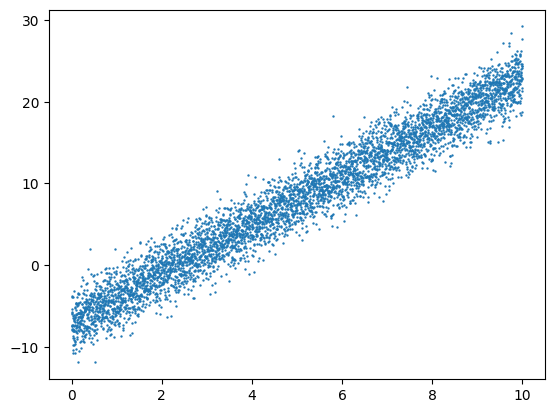

In [4]:
# generate data
X_data, y_true = generate_linear_data(3, -7, 5000)

# plotdata
plt.scatter(X_data, y_true, s=0.5)
None

## Model specification

Instead of manually deriving expressions for the derivative of the loss with respect to the model parameters (see the [`Introduction to gradients`](../0_gradients_prologue/#representing-derivatives) notebook), we can now use a generalized neural network model that will compute derivatives automatically.

In [5]:
# define the model
list_layers = [Dense(1, 1)]
loss = MSE()
optimizer = SGD()
model = Sequential(list_layers, loss, optimizer)
model.summary()

Model layers:
    * Dense_0  | Dimensions: 1 x 1 | Parameters: 2
    --------------------
    Total parameters: 2


In [6]:
# check initial weights/parameters (randomly initialized)
model.layers[0].trainable

[('W', array([[0.16823658]]), array([[0.]])),
 ('b', array([[0.]]), array([[0.]]))]

## Run one training step

Once the model is defined, here is how to run a complete round of optimization.

In [7]:
# produce predictions
y_pred = model.forward(X_data)
y_pred.shape

(5000, 1)

In [8]:
# compute loss
loss = model.loss.forward(y_pred, y_true)
print(f"Initial loss: {loss}")

Initial loss: 121.30301609014472


In [9]:
# compute d_loss / d_ypred
d_loss = model.loss.backward()
d_loss.shape

(5000, 1)

In [10]:
# compute all the gradients dL/dw
grad = model.backward(d_loss)
grad.shape

(5000, 1)

In [11]:
# update weights
model.update_weights()

In [12]:
# check new, updated parameters
model.layers[0].trainable

[('W', array([[1.35411079]]), array([[-118.58742118]])),
 ('b', array([[0.14340042]]), array([[-14.34004193]]))]

In [13]:
# re-compute lsos (it should be lower!)
y_pred = model.forward(X_data)
loss = model.loss.forward(y_pred, y_true)
print(f"Loss after one training step: {loss}")

Loss after one training step: 27.219272518395844


## Run training epoch

In [14]:
# we can run all required training steps in one convenient function
loss = model.run_training_epoch(X_data, y_true)
print(f"Loss after two training steps: {loss}")

Loss after two training steps: 17.584748557184327


## Model training

Let us now train our model until it arrives to a good *enough* solution.

In [15]:
# let us run several epochs!
history = model.fit(X_data, y_true, 1000, debug_flag=True)

Epoch 1 - Loss: 16.499602224296943
Epoch 100 - Loss: 8.673907958904849
Epoch 200 - Loss: 5.7331580557499615
Epoch 300 - Loss: 4.630050662126348
Epoch 400 - Loss: 4.216263035860806
Epoch 500 - Loss: 4.061046779818835
Epoch 600 - Loss: 4.00282346764027
Epoch 700 - Loss: 3.980983267602678
Epoch 800 - Loss: 3.972790770133295
Epoch 900 - Loss: 3.969717674892852
Epoch 1000 - Loss: 3.968564923318362


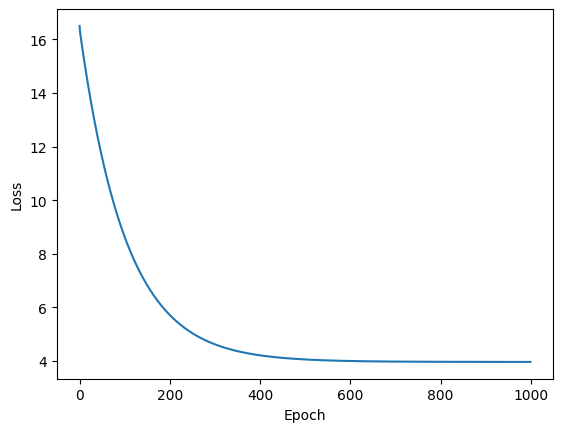

In [16]:
# get loss values from history
loss = history["loss"]

# compute average loss between batches
avg_loss = loss.mean(axis=1)

# plot
plt.plot(avg_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
None

## Evaluation

After training the model, we can check how well it performs by comparing its predictions to the actual outputs in the training data.

In [17]:
# let us print the final optimized parameters
for name, param, grad in model.layers[0].trainable:
    print(f"{name}: {param.item():.2f}")

W: 2.97
b: -6.84


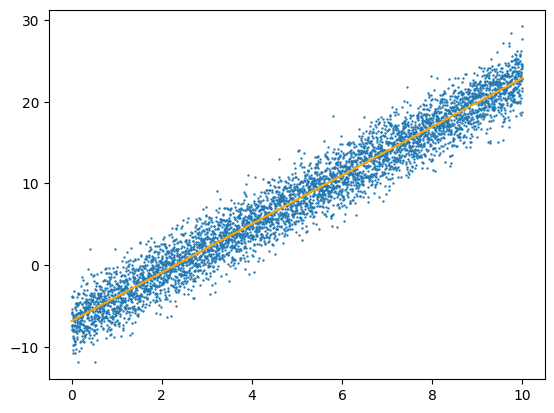

In [18]:
# how well do these parameters fit our data?
y_pred = model.forward(X_data)

plt.scatter(X_data, y_true, s=0.5)
plt.plot(X_data, y_pred, color='orange')
None